In [1]:
ls

'imperva log size.tsv'   Untitled.ipynb


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 5.2 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 6.7 MB/s eta 0:00:007.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.7 MB/s eta 0:00:00 MB/s eta 0:00:01


<Figure size 1400x700 with 0 Axes>

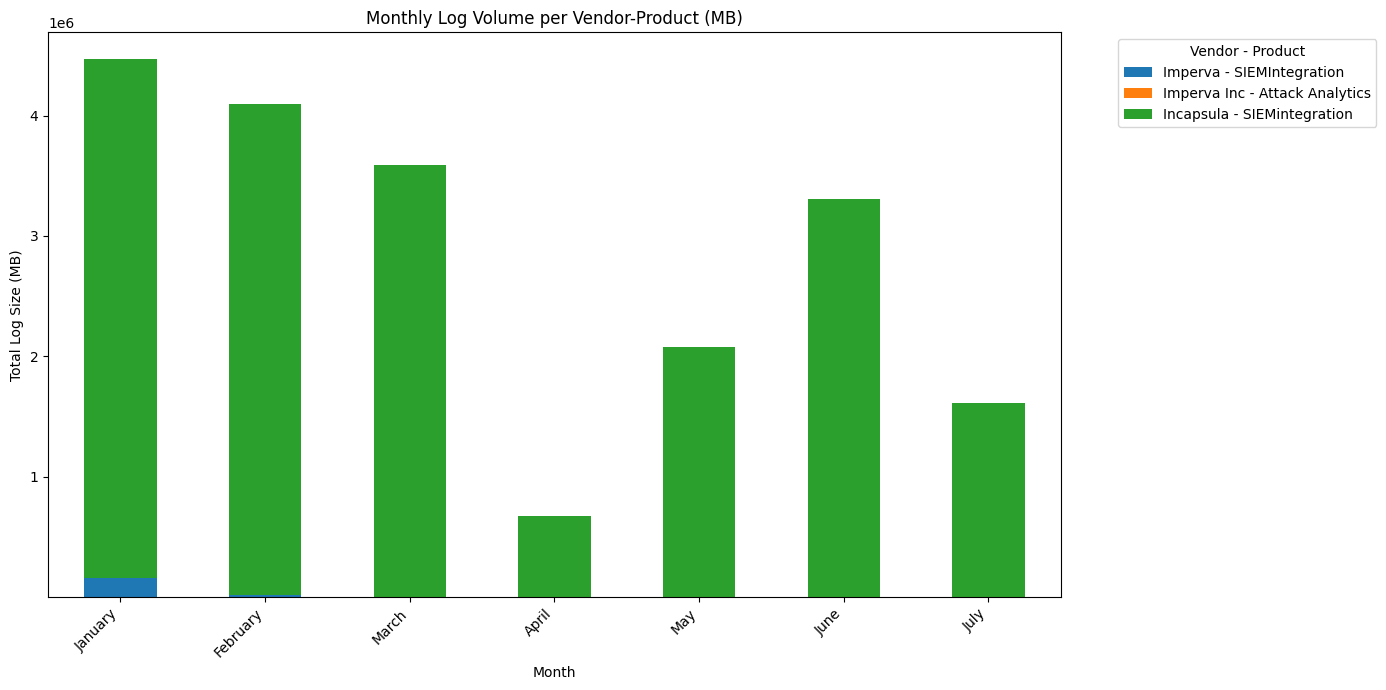

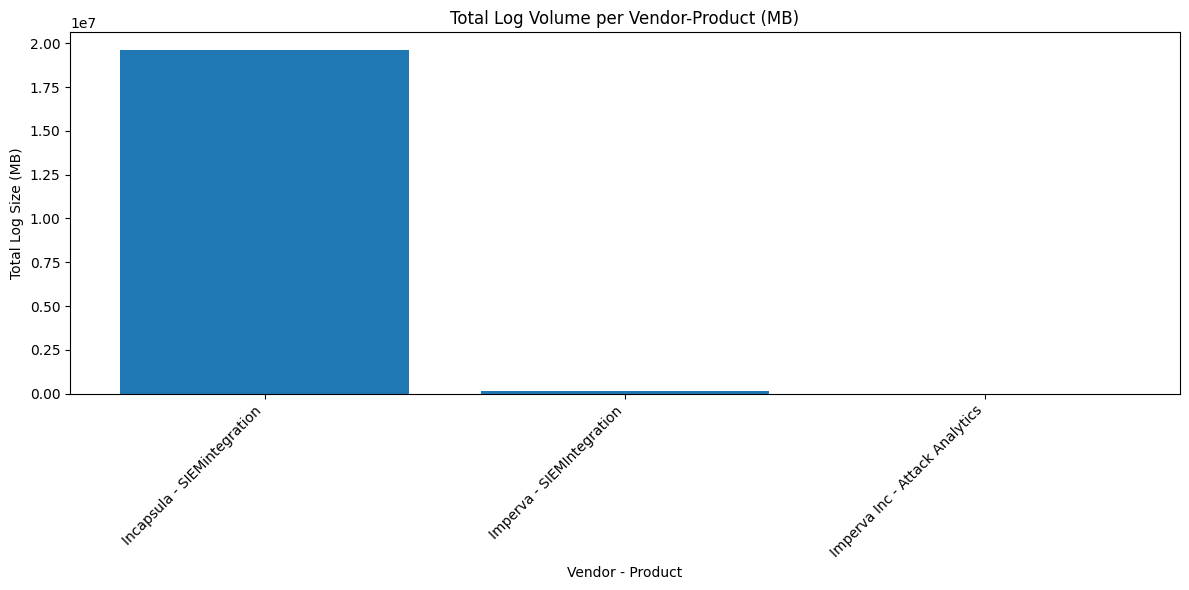

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data ===
df = pd.read_csv("imperva log size.tsv", sep="\t")

# Ensure correct dtypes
df['in_month_sort'] = df['in_month_sort'].astype(int)
df['Total'] = df['Total'].astype(float)

# Create a combined label for vendor + product
df['vendor_product'] = df['_vendor'] + " - " + df['_product']

# === 2. Aggregate per month & vendor_product ===
monthly_vp = (
    df.groupby(['in_month_sort', 'in_month', 'vendor_product'], as_index=False)['Total']
      .sum()
)

# Keep month order using in_month_sort
monthly_vp = monthly_vp.sort_values(['in_month_sort', 'vendor_product'])

# Pivot for plotting: rows = month, columns = vendor_product
pivot_monthly = monthly_vp.pivot_table(
    index=['in_month_sort', 'in_month'],
    columns='vendor_product',
    values='Total',
    fill_value=0
)

# For nicer x-axis labels, use month name only
pivot_monthly.index = pivot_monthly.index.set_names(['month_num', 'month_name'])
pivot_monthly = pivot_monthly.reset_index().set_index('month_name').drop(columns='month_num')

# === 3. Stacked bar chart per month (by vendor+product) ===
plt.figure(figsize=(14, 7))
pivot_monthly.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7)
)

plt.title("Monthly Log Volume per Vendor-Product (MB)")
plt.xlabel("Month")
plt.ylabel("Total Log Size (MB)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Vendor - Product", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# === 4. Total volume per vendor+product across all months ===
total_vp = (
    df.groupby('vendor_product', as_index=False)['Total']
      .sum()
      .sort_values('Total', ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(total_vp['vendor_product'], total_vp['Total'])
plt.title("Total Log Volume per Vendor-Product (MB)")
plt.xlabel("Vendor - Product")
plt.ylabel("Total Log Size (MB)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [5]:
df

,Total,in_month,_vendor,_product,in_month_sort,vendor_product
0,4308552.0,January,Incapsula,SIEMintegration,1,Incapsula - SIEMintegration
1,159774.0,January,Imperva,SIEMIntegration,1,Imperva - SIEMIntegration
2,3.0,January,Imperva Inc,Attack Analytics,1,Imperva Inc - Attack Analytics
3,3.0,February,Imperva Inc,Attack Analytics,2,Imperva Inc - Attack Analytics
4,4078565.0,February,Incapsula,SIEMintegration,2,Incapsula - SIEMintegration
5,18177.0,February,Imperva,SIEMIntegration,2,Imperva - SIEMIntegration
6,5.0,March,Imperva Inc,Attack Analytics,3,Imperva Inc - Attack Analytics
7,3588626.0,March,Incapsula,SIEMintegration,3,Incapsula - SIEMintegration
8,5.0,April,Imperva Inc,Attack Analytics,4,Imperva Inc - Attack Analytics
9,677318.0,April,Incapsula,SIEMintegration,4,Incapsula - SIEMintegration


In [6]:
df.to_excel("imperva log size.xlsx")